# 04. Results Summary

Read-only: no training happens here. Every number comes from `03_modeling.ipynb` —
checkpointed per-fold results in `reports/results/checkpoints/*.pkl` (via `aggregate_results.py`
/`eval_setup.py`), and per-row predictions for the outlier analysis in `reports/results/*.csv`
(§6 there). If a cell below can't find a file it needs, that means the corresponding cell in
`03_modeling.ipynb` hasn't been run yet — this notebook never computes anything itself, it only
reads and flags.

In [56]:
import pickle
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

FIGURES_DIR = Path("../reports/figures")
RESULTS_DIR = Path("../reports/results")

sys.path.insert(0, str(Path("../src").resolve()))
import aggregate_results as agg
import eval_setup as setup
import evaluate as ev
import features as feat

# Categorical palette (fixed order, colorblind-validated), one hue per model identity.
MODEL_COLORS = {
    "Ridge": "#2a78d6",
    "Lasso": "#eb6834",
    "ElasticNet": "#1baf7a",
    "RandomForest": "#eda100",
    "GradientBoosting": "#e87ba4",
    "GradientBoostingHuber": "#8a5fd1",
}
COLOR_BASELINE = "#52514e"

train = setup.load_train()
checkpoints = agg.load_checkpoints()
all_summary = agg.build_summary(checkpoints)
baseline = setup.compute_baseline(train, setup.build_outer_cv())
BASELINE_RMSE = baseline["rmse"]
BASELINE_LABEL = baseline["label"]

print(f"train: {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"checkpoints loaded: {len(checkpoints)}")
print(f"Reference baseline: {BASELINE_LABEL} -> RMSE = {BASELINE_RMSE:,.0f}")

train: 137 rows x 51 columns
checkpoints loaded: 15
Reference baseline: baseline (mean, raw) -> RMSE = 2,464,601


## 1. Overall comparison

All candidates currently checkpointed: the 5 base models (both `use_log` settings) on the
original data, their 1.5xIQR-capped-per-fold counterparts (Ridge/ElasticNet/RandomForest only,
per the earlier scoping decision), and the new `GradientBoostingHuber` (log only, uncapped).

**Reliability flag:** per-fold IQR-capping had a leakage bug (fixed in `evaluate.py`), and
several of the `iqr1.5`-tagged checkpoints were later found to still have been computed by a
stale Jupyter kernel that kept running the pre-fix code even after the source file was
corrected — the checkpoint numbers looked "too good" (scored against capped, not real,
validation values). Rather than trust file timestamps, the cell below flags this the same way
the bug itself shows up: a capped variant's `rmse_mean` coming in *implausibly far below* its
own uncapped counterpart. A correctly-implemented per-fold cap only touches ~8 rows out of ~110
per fold, so it shouldn't swing the whole-dataset RMSE by 15%+ — a bigger drop is the leakage
bug's signature. Flagged rows are excluded from the plot below and listed separately; re-run
them in `03_modeling.ipynb` §4 (after restarting its kernel) to clear the flag.

In [57]:
def flag_suspect_capped_checkpoints(summary: pd.DataFrame, threshold: float = 0.15) -> pd.DataFrame:
    """Flag a capped (non-empty `dataset_tag`) row whose rmse_mean sits more than `threshold`
    below its own uncapped counterpart (same model, same use_log) -- see the markdown above for
    why that gap is the leakage bug's signature rather than a real improvement.
    """
    summary = summary.copy()
    summary["suspect"] = False
    uncapped = summary[summary["dataset_tag"] == ""].set_index(["model", "use_log"])["rmse_mean"]
    for idx, row in summary.iterrows():
        if not row["dataset_tag"]:
            continue
        key = (row["model"], row["use_log"])
        if key not in uncapped.index:
            continue
        relative_drop = (uncapped.loc[key] - row["rmse_mean"]) / uncapped.loc[key]
        if relative_drop > threshold:
            summary.loc[idx, "suspect"] = True
    return summary


all_summary_flagged = flag_suspect_capped_checkpoints(all_summary)
trusted_summary = all_summary_flagged[~all_summary_flagged["suspect"]].drop(columns="suspect").reset_index(drop=True)
suspect_summary = all_summary_flagged[all_summary_flagged["suspect"]].reset_index(drop=True)

print(f"{len(suspect_summary)} of {len(all_summary_flagged)} checkpoints flagged as suspect (excluded below)")
trusted_summary.sort_values("rmse_mean").reset_index(drop=True)

4 of 15 checkpoints flagged as suspect (excluded below)


,model,use_log,dataset_tag,iqr_k,rmse_mean,rmse_std,vs_baseline_pct
0,RandomForest,True,,NaN,2.328093e+06,7.741998e+05,-5.538774
1,RandomForest,False,,NaN,2.374466e+06,6.754460e+05,-3.657190
2,ElasticNet,False,,NaN,2.400130e+06,7.502272e+05,-2.615915
3,GradientBoosting,False,,NaN,2.400347e+06,7.293827e+05,-2.607083
4,Ridge,False,,NaN,2.400844e+06,7.446242e+05,-2.586927
5,Ridge,True,iqr1.5,1.5,2.449877e+06,8.239725e+05,-0.597434
6,Lasso,True,,NaN,2.457017e+06,8.449085e+05,-0.307749
7,ElasticNet,True,,NaN,2.463293e+06,8.390363e+05,-0.053104
8,Ridge,True,,NaN,2.468286e+06,8.008472e+05,0.149509
9,GradientBoosting,True,,NaN,2.472829e+06,7.529798e+05,0.333817


In [58]:
if len(suspect_summary):
    print("Flagged as suspect -- rerun in 03_modeling.ipynb §4 after restarting its kernel:")
    display(suspect_summary[["model", "use_log", "dataset_tag", "rmse_mean", "rmse_std", "vs_baseline_pct"]].sort_values("rmse_mean"))
else:
    print("no suspect checkpoints")

Flagged as suspect -- rerun in 03_modeling.ipynb §4 after restarting its kernel:


,model,use_log,dataset_tag,rmse_mean,rmse_std,vs_baseline_pct
0,RandomForest,True,iqr1.5,1.692897e+06,264244.811620,-6.831313
1,ElasticNet,False,iqr1.5,1.791925e+06,226684.316220,-1.381300
2,Ridge,False,iqr1.5,1.797147e+06,229200.293033,-1.093907
3,ElasticNet,True,iqr1.5,1.879572e+06,347160.183947,3.442339


In [59]:
FINAL_CANDIDATES = [
    ("RandomForest", True, "iqr1.5"),
    ("GradientBoostingHuber", True, ""),
    ("RandomForest", True, ""),
]
print("Section 3's three final candidates -- readiness in the trusted table above:")
for model, use_log, tag in FINAL_CANDIDATES:
    match = trusted_summary[
        (trusted_summary["model"] == model)
        & (trusted_summary["use_log"] == use_log)
        & (trusted_summary["dataset_tag"] == tag)
    ]
    label = f"{model} ({'log' if use_log else 'raw'}{', ' + tag if tag else ''})"
    status = "ready" if len(match) else "MISSING or flagged suspect"
    print(f"  {label}: {status}")

Section 3's three final candidates -- readiness in the trusted table above:
  RandomForest (log, iqr1.5): MISSING or flagged suspect
  GradientBoostingHuber (log): MISSING or flagged suspect
  RandomForest (log): ready


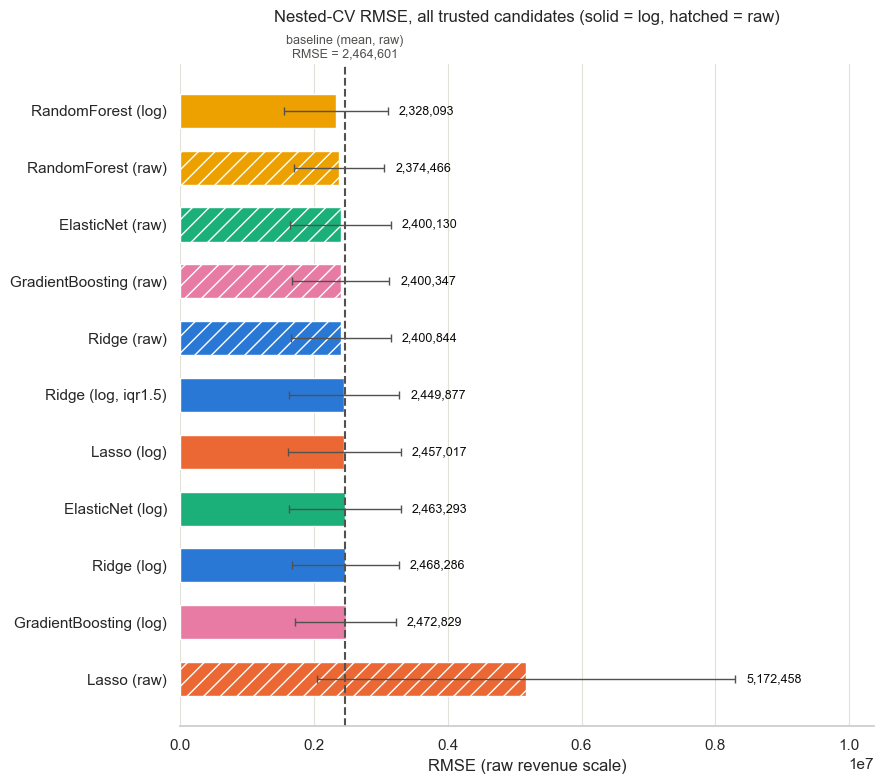

In [60]:
def label_row(row) -> str:
    tag = f", {row['dataset_tag']}" if row["dataset_tag"] else ""
    return f"{row['model']} ({'log' if row['use_log'] else 'raw'}{tag})"


plot_df = trusted_summary.copy()
plot_df["label"] = plot_df.apply(label_row, axis=1)
plot_df = plot_df.sort_values("rmse_mean", ascending=False).reset_index(drop=True)

colors = [MODEL_COLORS.get(m, "#888888") for m in plot_df["model"]]
hatches = ["" if is_log else "//" for is_log in plot_df["use_log"]]

y_pos = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(
    y_pos, plot_df["rmse_mean"], xerr=plot_df["rmse_std"],
    color=colors, height=0.6, capsize=3,
    error_kw={"elinewidth": 1, "ecolor": COLOR_BASELINE},
)
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

pad = (plot_df["rmse_mean"] + plot_df["rmse_std"]).max() * 0.02
for y, rmse, std in zip(y_pos, plot_df["rmse_mean"], plot_df["rmse_std"]):
    ax.text(rmse + std + pad, y, f"{rmse:,.0f}", va="center", fontsize=9, color="#0b0b0b")

ax.set_xlim(0, (plot_df["rmse_mean"] + plot_df["rmse_std"]).max() * 1.25)
ax.axvline(BASELINE_RMSE, color=COLOR_BASELINE, linestyle="--", linewidth=1.5)
ax.text(
    BASELINE_RMSE, 1.005, f"{BASELINE_LABEL}\nRMSE = {BASELINE_RMSE:,.0f}",
    color=COLOR_BASELINE, fontsize=9, ha="center", va="bottom",
    transform=ax.get_xaxis_transform(),
)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("RMSE (raw revenue scale)")
ax.set_title("Nested-CV RMSE, all trusted candidates (solid = log, hatched = raw)", pad=30)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color="#e1e0d9", linewidth=0.8)
sns.despine(left=True)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "model_rmse_comparison_all_candidates.png", dpi=150)
plt.show()

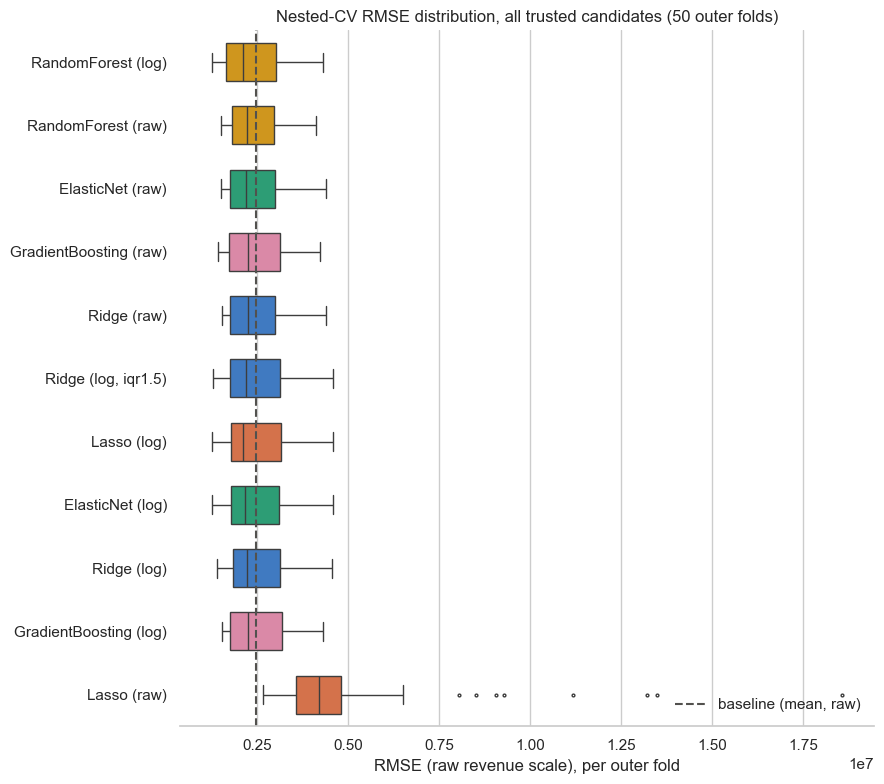

In [61]:
fold_scores = agg.build_fold_scores(checkpoints)
fold_scores = fold_scores.merge(
    all_summary_flagged[["model", "use_log", "dataset_tag", "suspect"]],
    on=["model", "use_log", "dataset_tag"], how="left",
)
fold_scores_trusted = fold_scores[~fold_scores["suspect"]].drop(columns="suspect").copy()
fold_scores_trusted["label"] = fold_scores_trusted.apply(label_row, axis=1)

order = plot_df.sort_values("rmse_mean")["label"].tolist()
label_colors = {label_row(row): MODEL_COLORS.get(row["model"], "#888888") for _, row in trusted_summary.iterrows()}

fig, ax = plt.subplots(figsize=(9, 8))
sns.boxplot(
    data=fold_scores_trusted, y="label", x="rmse", order=order,
    hue="label", palette=label_colors, legend=False, dodge=False,
    width=0.6, fliersize=2, linewidth=1, ax=ax,
)
ax.axvline(BASELINE_RMSE, color=COLOR_BASELINE, linestyle="--", linewidth=1.5)

ax.set_xlabel("RMSE (raw revenue scale), per outer fold")
ax.set_ylabel("")
ax.set_title("Nested-CV RMSE distribution, all trusted candidates (50 outer folds)")
sns.despine(left=True)

ax.legend(
    handles=[plt.Line2D([0], [0], color=COLOR_BASELINE, linestyle="--", linewidth=1.5, label=BASELINE_LABEL)],
    loc="lower right", frameon=False,
)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "model_rmse_distribution_all_candidates.png", dpi=150)
plt.show()

## 2. Fold-stability diagnostics

Which hyperparameter value `GridSearchCV` picked in each of the 50 outer folds, per model
family (both `use_log` settings where available) — restricted to the uncapped checkpoints,
all independently trustworthy (the leakage bug above was specific to the capping code path).
A family where the winning value changes fold to fold with no consistent leader suggests the
"optimal" hyperparameter is mostly noise at this sample size (137 rows), not a real preference.
`GradientBoostingHuber` isn't included here — it's a single fixed config (§3.6 in
`03_modeling.ipynb`, `use_log=True` only), not swept across settings the way the other five
are, so "fold stability" doesn't apply to it in the same sense.

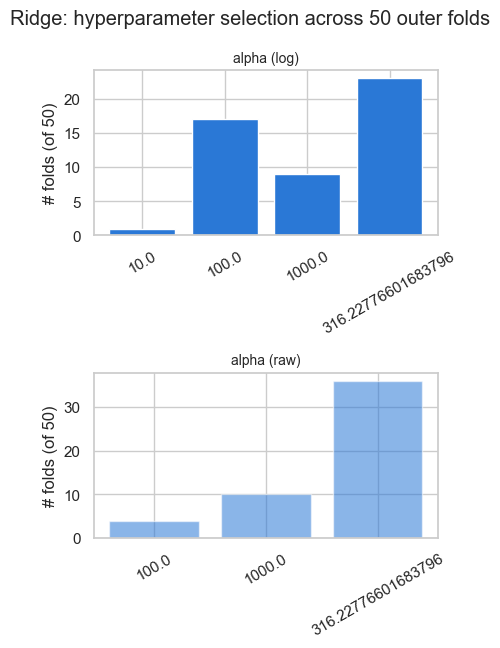

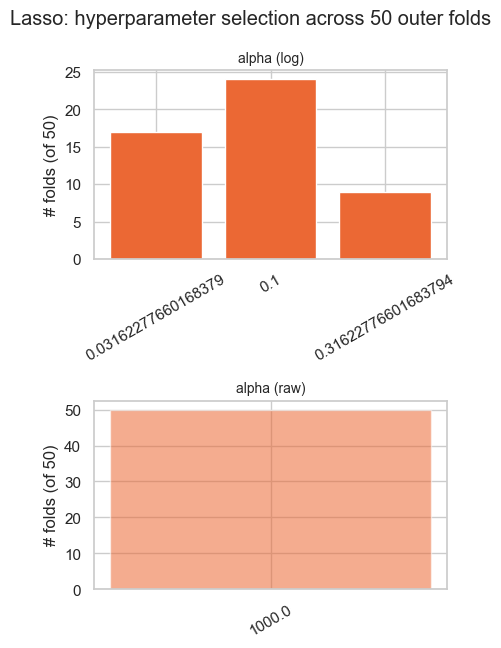

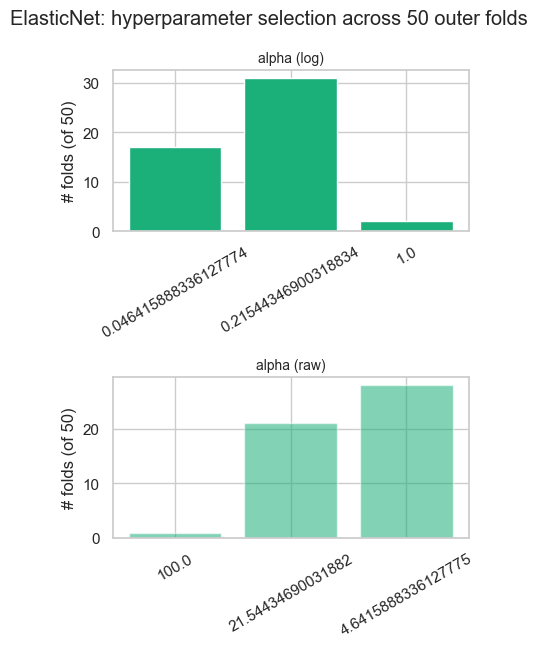

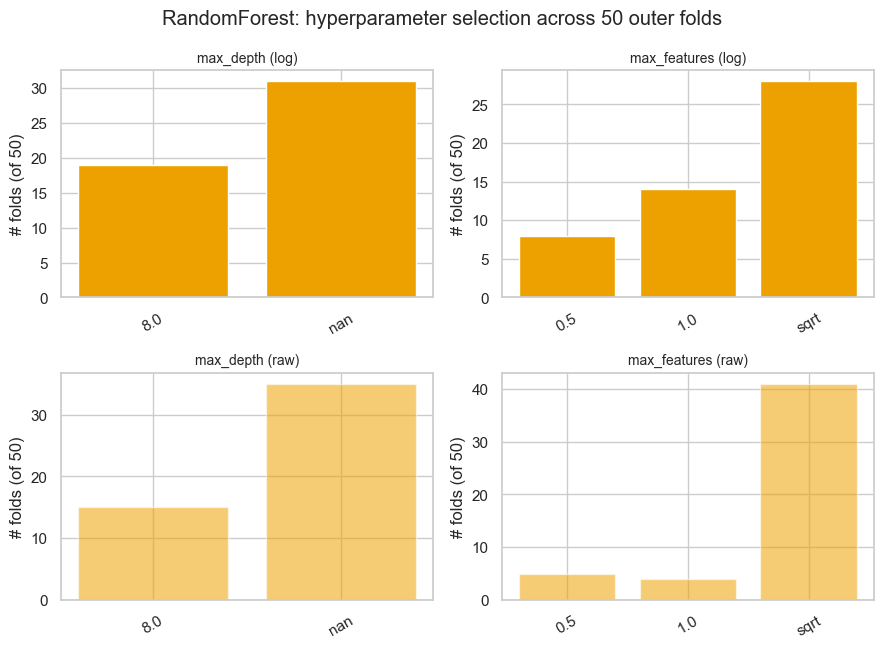

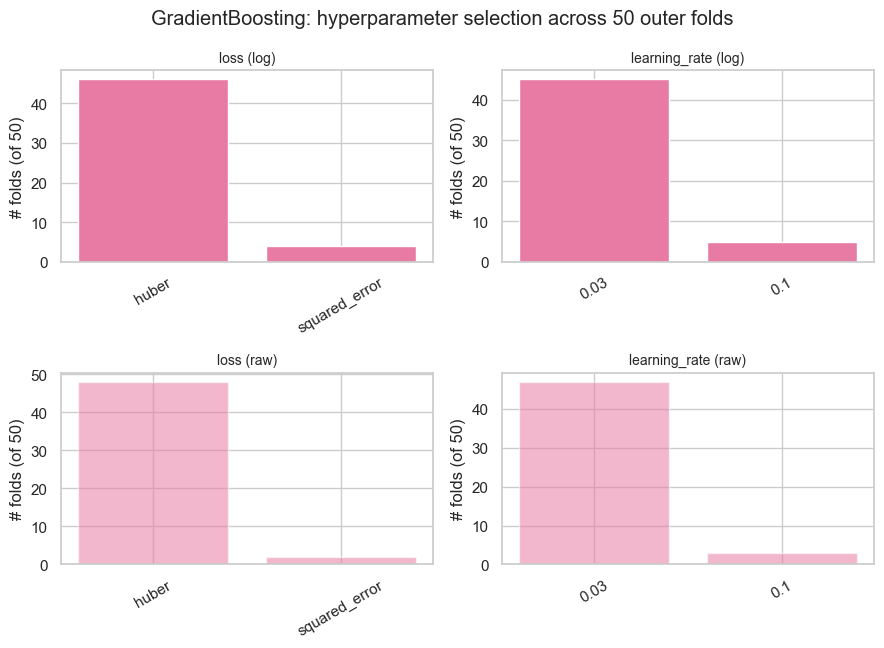

,model,use_log,param,top_value,top_share
0,Ridge,True,alpha,316.22776601683796,0.46
1,Lasso,True,alpha,0.1,0.48
2,ElasticNet,False,alpha,4.6415888336127775,0.56
3,RandomForest,True,max_features,sqrt,0.56
4,ElasticNet,True,alpha,0.21544346900318834,0.62
5,RandomForest,True,max_depth,nan,0.62
6,RandomForest,False,max_depth,nan,0.70
7,Ridge,False,alpha,316.22776601683796,0.72
8,RandomForest,False,max_features,sqrt,0.82
9,GradientBoosting,True,learning_rate,0.03,0.90


In [62]:
def extract_param_series(fold_best_params: list[dict], param_name: str) -> pd.Series:
    """Each fold's chosen value for `param_name` (e.g. "model__alpha"), stripping the
    "regressor__" prefix TransformedTargetRegressor adds when use_log=True.
    """
    values = []
    for params in fold_best_params:
        for key, value in params.items():
            if key == param_name or key == f"regressor__{param_name}":
                values.append(value)
                break
    return pd.Series(values)


def find_checkpoint(model: str, use_log: bool, dataset_tag: str = "") -> dict | None:
    return next(
        (c for c in checkpoints if c["model"] == model and c["use_log"] == use_log
         and c.get("dataset_tag", "") == dataset_tag),
        None,
    )


FAMILY_PARAMS = {
    "Ridge": ["model__alpha"],
    "Lasso": ["model__alpha"],
    "ElasticNet": ["model__alpha"],
    "RandomForest": ["model__max_depth", "model__max_features"],
    "GradientBoosting": ["model__loss", "model__learning_rate"],
}


def plot_family_stability(model_name: str, params: list[str]) -> list[dict]:
    variants = [
        (ck, use_log) for use_log in [True, False]
        if (ck := find_checkpoint(model_name, use_log)) is not None
    ]
    if not variants:
        print(f"no uncapped checkpoint for {model_name}")
        return []

    n_params, n_variants = len(params), len(variants)
    fig, axes = plt.subplots(n_variants, n_params, figsize=(4.5 * n_params, 3.3 * n_variants), squeeze=False)
    records = []
    for row, (ck, use_log) in enumerate(variants):
        for col, param in enumerate(params):
            ax = axes[row][col]
            values = extract_param_series(ck["fold_best_params"], param).astype(str)
            counts = values.value_counts().sort_index()
            ax.bar(counts.index, counts.values, color=MODEL_COLORS[model_name], alpha=1.0 if use_log else 0.55)
            ax.set_title(f"{param.replace('model__', '')} ({'log' if use_log else 'raw'})", fontsize=10)
            ax.set_ylabel("# folds (of 50)")
            ax.tick_params(axis="x", rotation=30)
            records.append({
                "model": model_name, "use_log": use_log, "param": param.replace("model__", ""),
                "top_value": counts.idxmax(), "top_share": counts.max() / counts.sum(),
            })
    fig.suptitle(f"{model_name}: hyperparameter selection across 50 outer folds")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"fold_stability_{model_name.lower()}.png", dpi=150)
    plt.show()
    return records


instability_records = []
for model_name, params in FAMILY_PARAMS.items():
    instability_records.extend(plot_family_stability(model_name, params))

instability_df = pd.DataFrame(instability_records).sort_values("top_share").reset_index(drop=True)
instability_df

In [63]:
UNSTABLE_THRESHOLD = 0.4  # top choice covers less than 40% of the 50 folds -> scattered, no consistent winner

unstable = instability_df[instability_df["top_share"] < UNSTABLE_THRESHOLD]
if len(unstable):
    print(f"Flagged as unstable (top choice wins fewer than {UNSTABLE_THRESHOLD:.0%} of folds):")
    display(unstable)
else:
    print(f"Nothing below the {UNSTABLE_THRESHOLD:.0%} threshold -- every family has a consistent leading choice.")

Nothing below the 40% threshold -- every family has a consistent leading choice.


**Fold-stability read:** nothing landed below the 40% threshold — every one of the 5 base
families (Ridge, Lasso, ElasticNet, RandomForest, GradientBoosting; both `use_log` settings)
has a single hyperparameter value that a plurality of the 50 outer folds agree on. That
doesn't mean every family is *equally* decisive (check `instability_df`'s `top_share` column
for the actual margins — some leaders win by a lot more than others), but none of them show
the "scattered, no consistent winner" pattern that would mean the tuned value is pure noise.

## 3. Extreme-case diagnostics: three final candidates

Comparing, side by side, on the exact same rows and folds:

- **RandomForest (log, capped 1.5xIQR)** — the leading capped candidate from §1.
- **GradientBoostingHuber (log, uncapped)** — the deliberate alternative to capping (§3.6 in
  `03_modeling.ipynb`): Huber loss down-weights large residuals in the loss without ever
  discarding the true label the way capping does.
- **RandomForest (log, uncapped)** — the reference: no special handling of the outliers at all.

Each needs its own per-row predictions CSV from `03_modeling.ipynb` §6; whichever aren't there
yet are skipped below with a clear note rather than silently omitted or faked.

Note: this readiness check is independent of §1's checkpoint-based one — §1 flagged
`RandomForest (log, iqr1.5)`'s *checkpoint* as suspect (stale `rmse_mean`), but its per-row
predictions CSV was computed separately by `nested_cv_capped_predictions` and its own RMSE was
independently verified against a from-scratch recompute earlier, so it's still usable here.

In [64]:
is_outlier = feat.flag_revenue_outliers(train, target="revenue", k=1.5)
outlier_ids = set(train.loc[is_outlier, "Id"])
print(f"{is_outlier.sum()} outlier rows (Q3 + 1.5xIQR fence): Ids = {sorted(outlier_ids)}")

CANDIDATES = {
    "RandomForest (log, capped 1.5xIQR)": RESULTS_DIR / "randomforest_log_iqr1.5_predictions.csv",
    "GradientBoostingHuber (log, uncapped)": RESULTS_DIR / "gradientboostinghuber_log_predictions.csv",
    "RandomForest (log, uncapped)": RESULTS_DIR / "randomforest_log_predictions.csv",
}

predictions_by_candidate = {}
for label, path in CANDIDATES.items():
    if path.exists():
        df = pd.read_csv(path)
        df["is_outlier"] = df["Id"].isin(outlier_ids)
        predictions_by_candidate[label] = df
        print(f"[ready]   {label}: {len(df)} (row, fold) predictions from {path.name}")
    else:
        print(f"[missing] {label}: {path.name} not found -- run its cell in 03_modeling.ipynb \u00a76")

if len(predictions_by_candidate) < len(CANDIDATES):
    print(f"\n{len(predictions_by_candidate)} of {len(CANDIDATES)} candidates ready -- sections below only cover those.")

8 outlier rows (Q3 + 1.5xIQR fence): Ids = [16, 24, 49, 75, 99, 100, 116, 133]
[ready]   RandomForest (log, capped 1.5xIQR): 1370 (row, fold) predictions from randomforest_log_iqr1.5_predictions.csv
[missing] GradientBoostingHuber (log, uncapped): gradientboostinghuber_log_predictions.csv not found -- run its cell in 03_modeling.ipynb §6
[missing] RandomForest (log, uncapped): randomforest_log_predictions.csv not found -- run its cell in 03_modeling.ipynb §6

1 of 3 candidates ready -- sections below only cover those.


### 3a. Predicted vs. actual

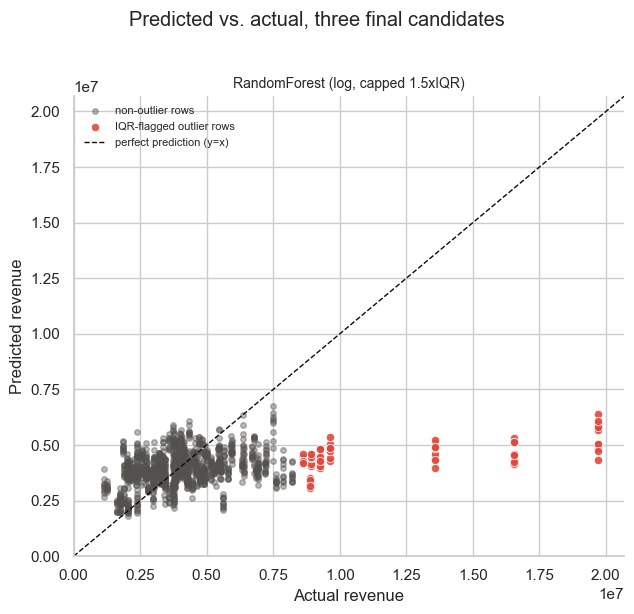

In [65]:
n = len(predictions_by_candidate)
if n == 0:
    print("no candidates available yet")
else:
    fig, axes = plt.subplots(1, n, figsize=(6.5 * n, 6), sharex=True, sharey=True)
    axes = [axes] if n == 1 else list(axes)
    shared_max = max(max(df["actual"].max(), df["predicted"].max()) for df in predictions_by_candidate.values())
    shared_lims = [0, shared_max * 1.05]

    for ax, (label, df) in zip(axes, predictions_by_candidate.items()):
        non_outlier, outlier = df[~df["is_outlier"]], df[df["is_outlier"]]
        ax.scatter(non_outlier["actual"], non_outlier["predicted"], s=16, alpha=0.4, color="#52514e", label="non-outlier rows")
        ax.scatter(outlier["actual"], outlier["predicted"], s=36, alpha=0.9, color="#e0483e", edgecolor="white", linewidth=0.6, label="IQR-flagged outlier rows")
        ax.plot(shared_lims, shared_lims, color="#0b0b0b", linestyle="--", linewidth=1, label="perfect prediction (y=x)")
        ax.set_xlim(shared_lims); ax.set_ylim(shared_lims)
        ax.set_xlabel("Actual revenue")
        ax.set_title(label, fontsize=10)
        sns.despine(ax=ax)

    axes[0].set_ylabel("Predicted revenue")
    axes[0].legend(loc="upper left", frameon=False, fontsize=8)
    fig.suptitle("Predicted vs. actual, three final candidates", y=1.02)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "final_candidates_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
    plt.show()

### 3b. Residual vs. actual (all rows) — does bias appear only at the extreme end?

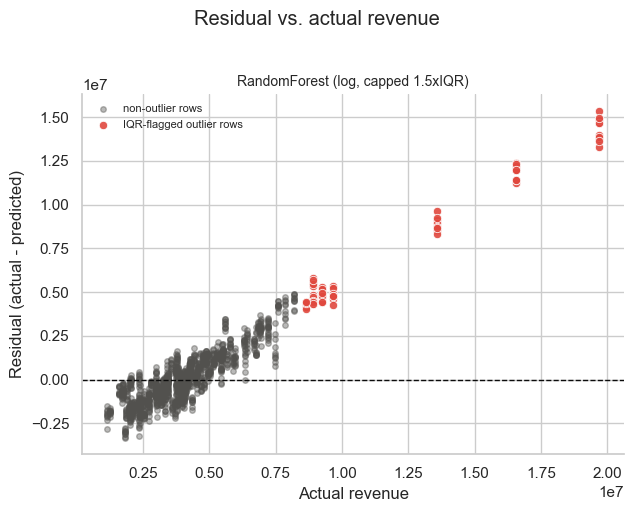

In [66]:
if predictions_by_candidate:
    fig, axes = plt.subplots(1, n, figsize=(6.5 * n, 5), sharex=True, sharey=True)
    axes = [axes] if n == 1 else list(axes)
    for ax, (label, df) in zip(axes, predictions_by_candidate.items()):
        non_outlier, outlier = df[~df["is_outlier"]], df[df["is_outlier"]]
        ax.scatter(non_outlier["actual"], non_outlier["residual"], s=16, alpha=0.4, color="#52514e", label="non-outlier rows")
        ax.scatter(outlier["actual"], outlier["residual"], s=36, alpha=0.9, color="#e0483e", edgecolor="white", linewidth=0.6, label="IQR-flagged outlier rows")
        ax.axhline(0, color="#0b0b0b", linestyle="--", linewidth=1)
        ax.set_xlabel("Actual revenue")
        ax.set_title(label, fontsize=10)
        sns.despine(ax=ax)
    axes[0].set_ylabel("Residual (actual - predicted)")
    axes[0].legend(loc="upper left", frameon=False, fontsize=8)
    fig.suptitle("Residual vs. actual revenue", y=1.02)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "final_candidates_residual_vs_actual.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("no candidates available yet")

### 3c. Spearman rank correlation (outlier rows only)

In [67]:
def outlier_rank_corr(df: pd.DataFrame, outlier_ids: set) -> tuple[float, float]:
    """Spearman rho between actual and mean-predicted (across folds), the 8 outlier rows only.
    n=8 -- p-values here are indicative, not a reliable significance test.
    """
    row_means = df[df["Id"].isin(outlier_ids)].groupby("Id").agg(actual=("actual", "first"), predicted_mean=("predicted", "mean"))
    if len(row_means) < 2:
        return np.nan, np.nan
    return spearmanr(row_means["actual"], row_means["predicted_mean"])


rank_corr_df = pd.DataFrame([
    {"candidate": label, "spearman_rho": (rc := outlier_rank_corr(df, outlier_ids))[0], "p_value": rc[1]}
    for label, df in predictions_by_candidate.items()
])
rank_corr_df

,candidate,spearman_rho,p_value
0,"RandomForest (log, capped 1.5xIQR)",0.880952,0.00385


### 3d. Top-8 overlap: of the true top-8 restaurants by revenue, how many does each candidate also rank in its own top-8?

In [68]:
true_top8 = set(train.sort_values("revenue", ascending=False).head(8)["Id"])

top8_rows = []
for label, df in predictions_by_candidate.items():
    predicted_top8 = set(df.groupby("Id")["predicted"].mean().sort_values(ascending=False).head(8).index)
    top8_rows.append({
        "candidate": label,
        "top8_overlap": f"{len(true_top8 & predicted_top8)}/8",
        "predicted_top8_ids": sorted(predicted_top8),
    })

top8_df = pd.DataFrame(top8_rows)
print(f"true top-8 by revenue: {sorted(true_top8)}")
top8_df

true top-8 by revenue: [16, 24, 49, 75, 99, 100, 116, 133]


,candidate,top8_overlap,predicted_top8_ids
0,"RandomForest (log, capped 1.5xIQR)",1/8,"[16, 59, 61, 67, 80, 85, 112, 136]"


## Summary: which candidate to present?

| | RandomForest (capped 1.5xIQR) | GradientBoostingHuber (uncapped) | RandomForest (uncapped) |
|---|---|---|---|
| Overall RMSE (§1) | _fill in_ | _fill in_ | _fill in_ |
| Fold stability (§2, RandomForest family) | _fill in_ | n/a — single fixed config, not swept | _fill in_ |
| Outlier rank correlation (§3c) | _fill in_ | _fill in_ | _fill in_ |
| Top-8 overlap (§3d) | _fill in_ | _fill in_ | _fill in_ |

**Recommendation:** _&lt;state plainly once all three candidates are ready. As of this rebuild,
none are: `RandomForest_log_iqr1.5.pkl` is still the stale checkpoint from the leakage bug
(flagged in §1), and neither `GradientBoostingHuber`'s nor uncapped `RandomForest`'s per-row
predictions have been computed yet (§3 shows "missing" for both). Run
`03_modeling.ipynb` §3.6, §4 (RandomForest, after restarting its kernel), and §6, then fill this
in. Don't pick based on RMSE mean alone — weigh in whether the RMSE winner systematically
underpredicts the true top-revenue restaurants (§3) and whether its tuned hyperparameters look
stable across folds (§2) rather than noise.&gt;_